In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact,fixed,widgets
opciones=dict(continuous_update=False)

#Reto 8
Elaborar un cuaderno interactivo de Colaboratory que permita visualizar el efecto capilar de un líquido.


Para ello:


1) Elabore una rutina en el que dadas la densidad ρ, y las viscosidades α₁₂, α₁₃, α₂₃ y el radio de un tubo capilar a, dibuje: en un panel el capilar mostrando hasta qué altura sube (o baja) el fluido y en otro panel la forma precisa del menisco que se forma dentro del capilar.  En los gráficos deben mostrarse los parámetros resultantes h, χ, R₀, d con sus unidades correspondientes.


2) Haga un código interactivo que permita controlar los 4 parámetros anteriores de modo que una persona pueda ver el efecto que tienen los parámetros de entrada sobre las propiedades del capilar.

##Tres medios
La teorería de young- Laplace permite describir situaciones que invoucran 2 medios en contacto, cuando tengo 3 medios, se debe generalizar

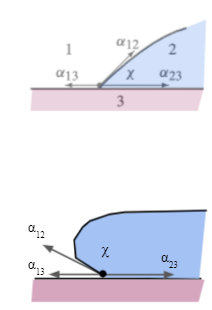

Tenemos 3 medios, cada uno con su propia energía superficial. El ángulo $\chi$ es crucial para llegar a la generalización, ya que esto nos dice si el fluido 2 tiende a formar gotas o humedece la superficie. 

Si $\alpha_{12} > \alpha_{23}$, el ángulo $\chi << 90$ entonces se dice que el medio 2 tiende a humedecer la superficie del medio 3

Si $\alpha_{13} < \alpha_{23}$, el ángulo $\chi > 90$ entonces se dice que el medio 2 tiende a formar gotas sobre la superficie 3

Este ángulo \phi también es crucial a la hora de encontrar el menisco, el cual se define como la superficie curva entre los 3 medios. Esta descrito por:

$$\cos \chi=\frac{\alpha_{13}-\alpha_{23}}{\alpha_{12}}$$

Donde $\alpha_{ij}$ es la tensión superficial entre el medio $i$ y el medio $j$

##El efecto capilar
En clase se vió que se define al efecto capilar como la tendencia de un fluido de ascender o descender por conductos debido a la presencia de un menisco en su superficie.

En clase se encontraron las ecuaciones que describen los 2 tipos de meniscos que se pueden encontrar en la naturaleza, tanto para curvatura positiva como para negativa.

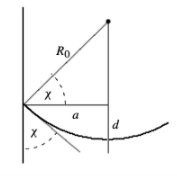

**Si el tubo es lo suficientemente delgado las fuerzas de tensión superficial en el menisco dominan sobre la gravedad, así, la forma del menisco es esférica**

En este caso:

$$a = R_0 \cos(\chi)$$

Donde $R_0$ es el radio de curvatura del menisco

La longitud de capilaridad:

$$R_c=\sqrt{\frac{\alpha}{\rho_0 g_0}}=\sqrt{\frac{\alpha_{12}}{\rho_0 g_0}}$$


$$$$

La altura del menisco es:

$$h = 2 \frac{R_c^2}{a}\cos(\chi)$$

$$$$

La profundidad del menisco es:

$$ d = R_0(1 - \sin(\chi))  $$

Procedimiento computacional:

Crearemos una función la cual nos entregue la gráfica del tubo capilar y otra con la forma del menisco, esto se hará de forma interactiva para poder analizar como cambia el efecto capilar de un líquido dependiendo de sus variables

interactive(children=(FloatSlider(value=0.7, continuous_update=False, description='alfa13', max=1.0, step=0.01…

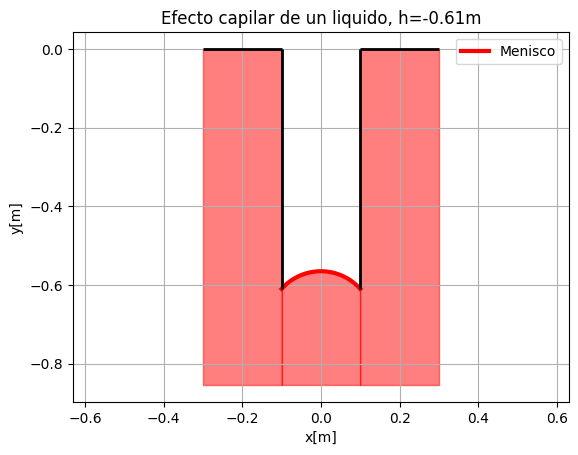

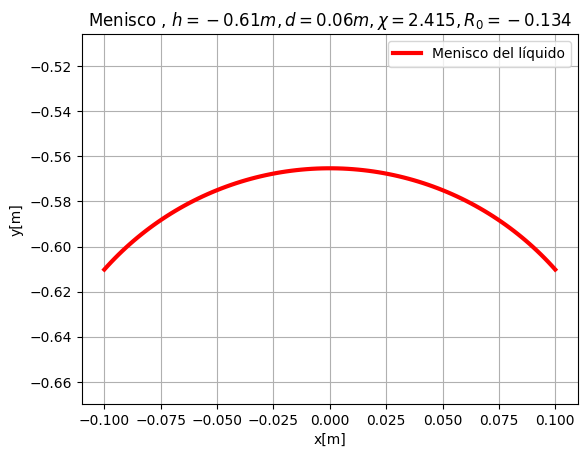

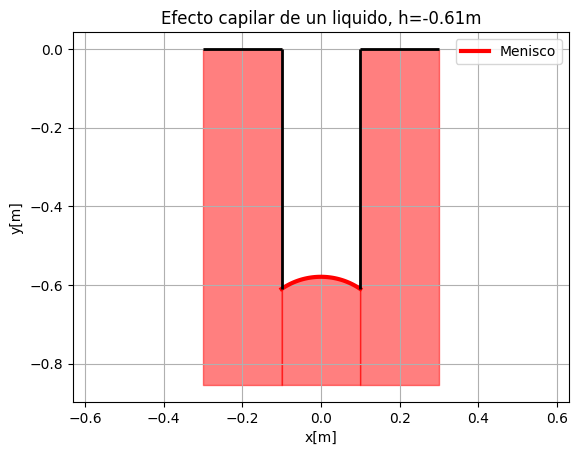

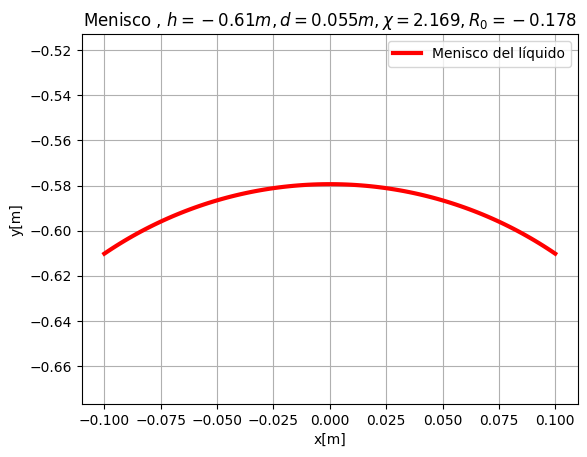

In [2]:
g=9.8

def menisco(alfa13=1.0,alfa23=1.2,alfa12=1.4,rho=1,a=0.1):
  cosfi=(alfa13-alfa23)/alfa12
  fi=np.arccos(cosfi)
  Rc=(alfa12/(rho*g))**0.5
  h=2*cosfi*(Rc**2)/a
  R0= a/np.cos(fi)
  d=R0*(1-np.sin(fi))/(np.cos(fi))
  #theta = np.linspace(np.pi/2-fi,np.pi-fi,1000)
  theta=np.linspace(np.pi+fi,2*np.pi-fi,100)
  xm= R0*np.cos(theta)
  ym =R0*np.sin(fi) + R0*np.sin(theta)+ h #R0 + R0*np.sin(theta) + h - d


  if h>0:
    plt.plot(xm,ym,c="blue", lw=3,label="Menisco")
    plt.title(f"Efecto capilar de un liquido, h={round(h,3)}m")
    plt.xlabel("x[m]")
    plt.ylabel("y[m]")
    plt.legend()
    plt.axis("equal")
    plt.grid()

    plt.vlines(x=R0*np.cos(np.pi+fi), ymin=0, ymax=h, colors='black', linestyles='-', lw=2)
    plt.vlines(x=R0*np.cos(2*np.pi-fi), ymin=0, ymax=h, colors='black', linestyles='-', lw=2)
    plt.hlines(y=0, xmin=2*R0*np.cos(np.pi+fi), xmax=R0*np.cos(np.pi+fi), colors='black', linestyles='-', lw=2)
    plt.hlines(y=0, xmin=R0*np.cos(2*np.pi-fi), xmax=2*R0*np.cos(2*np.pi-fi), colors='black', linestyles='-', lw=2)
    plt.fill_between(xm, 0, ym, color='#539ecd',alpha=0.5)

    plt.figure()
    plt.plot(xm,ym,c="blue", lw=3)
    plt.title(f"Menisco , h={round(h,3)}m, d={round(d,3)}m")
    plt.xlabel("x[m]")
    plt.ylabel("y[m]")
    plt.axis("equal")
    plt.grid()

  else:
    plt.plot(xm,ym,c="red", lw=3,label="Menisco")
    plt.title(f"Efecto capilar de un liquido, h={round(h,3)}m")
    plt.xlabel("x[m]")
    plt.ylabel("y[m]")
    plt.legend()
    plt.axis("equal")
    plt.grid()

    plt.vlines(x=R0*np.cos(np.pi+fi), ymin=0, ymax=h, colors='black', linestyles='-', lw=2)
    plt.vlines(x=R0*np.cos(2*np.pi-fi), ymin=0, ymax=h, colors='black', linestyles='-', lw=2)
    plt.hlines(y=0, xmin=3*R0*np.cos(np.pi+fi), xmax=R0*np.cos(np.pi+fi), colors='black', linestyles='-', lw=2)
    plt.hlines(y=0, xmin=R0*np.cos(2*np.pi-fi), xmax=3*R0*np.cos(2*np.pi-fi), colors='black', linestyles='-', lw=2)
    plt.fill_between(xm, ym, 1.4*h, color='red',alpha=0.5)
    x1=np.linspace(R0*np.cos(np.pi+fi),3*R0*np.cos(np.pi+fi),100)
    x2=np.linspace(R0*np.cos(2*np.pi-fi),3*R0*np.cos(2*np.pi-fi),100)
    plt.fill_between(x1, 0, 1.4*h, color='red',alpha=0.5)
    plt.fill_between(x2, 0, 1.4*h, color='red',alpha=0.5)

    plt.figure()
    plt.plot(xm,ym,c="red", lw=3,label="Menisco del líquido")
    plt.legend()
    plt.title(f"Menisco , $h={round(h,3)}m, d={round(d,3)}m, \chi = {round(fi,3)}, R_0 = {round(R0,3)}$")
    plt.xlabel("x[m]")
    plt.ylabel("y[m]")
    plt.axis("equal")
    plt.grid()


  #plt.hlines(y=-408.6, xmin=-0.50, xmax=0.50, colors='red', linestyles='-', lw=2)
  
  return 

# Código de interacción
interact(menisco,
         rho=widgets.FloatSlider(min=0.001,max=40,value=1,step=0.1,**opciones),
         alfa12=widgets.FloatSlider(min=0.001,max=1.0,value=0.4,step=0.01,**opciones),
         alfa23=widgets.FloatSlider(min=0,max=0.999,value=1,step=0.01,**opciones),
         alfa13=widgets.FloatSlider(min=0,max=1.0,value=0.7,step=0.01,**opciones),
         a=widgets.FloatSlider(min=0,max=0.1,value=0.1,step=0.01,**opciones)
         );

Como se pudo observar la relación entre el $\alpha_{13}$ y el $\alpha_{23}$ es crucial, ya que esto determinará si el líquido asciende o desciende por el tubo, además, también se pudo evidenciar como mientras más separados están estos 2 valores el radio de curvatura se hace más pequeño, mostrandonos un menisco más pronunciado y una altura mayor de ascenso o descenso.

Por el contrario le tensión superficial $\alpha_{12}$ no afecta en nada a la altura, pero si es crucial a la hora de la definición de la forma del menisco, esta tensión superficial es directamente proporcional al radio de curvatura, mientras más pequeño, más curvo es el menisco.

También es importante señalar que el area del tubo debe ser considerablemente pequeña, durante la tería hicimos esta aclaración, pero lo comprobamos en la realización del código, donde si se escoge un área muy grande el programa diverge.

Por último, se puede también ver que a medida que se cambia la densidad, la forma del menisco se mantiene constante, es decir, la densidad solo afecta a la altura.